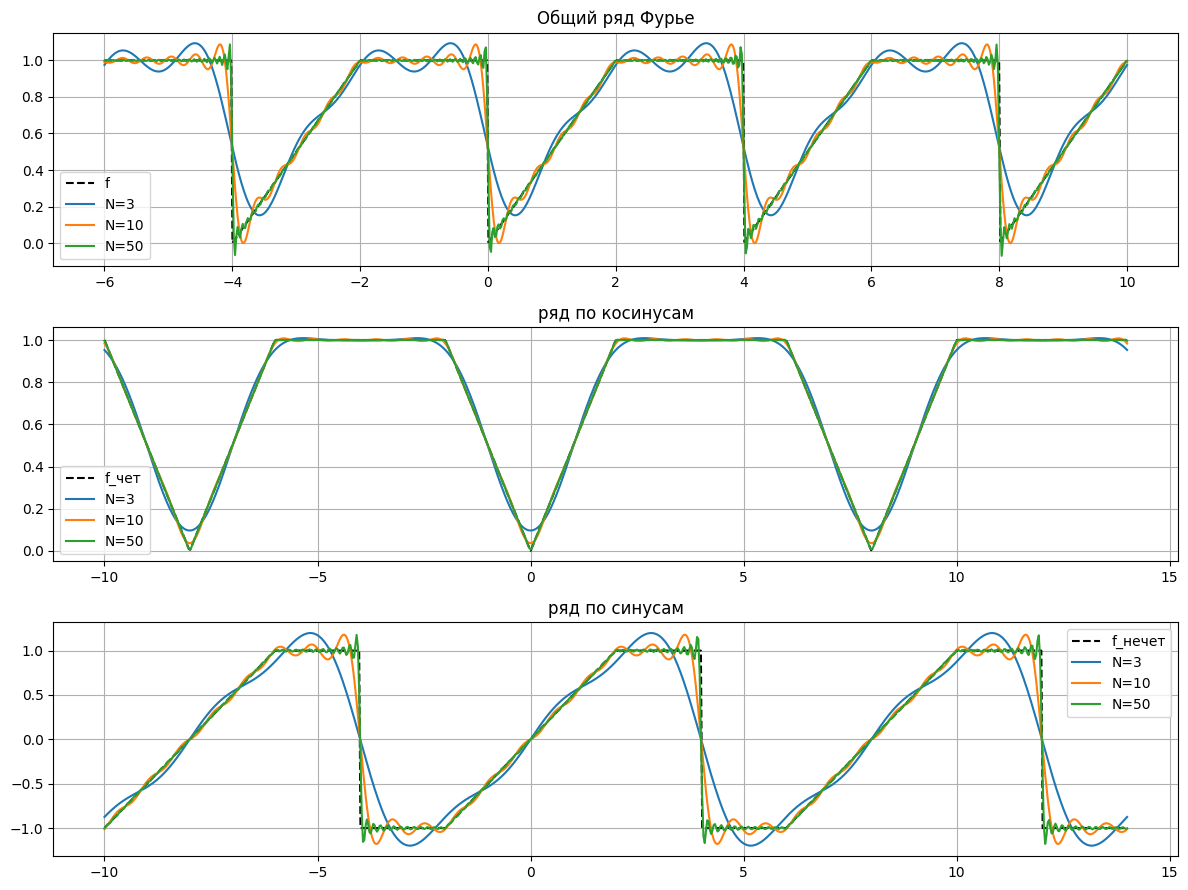

In [9]:
import numpy as np
import matplotlib.pyplot as plt

PI = np.pi

def f(x):
    t = x % 4
    if t < 2:
        return t / 2
    else:
        return 1.0

def main_series(x, N):
    s = np.full_like(x, 0.75)
    for k in range(1, N+1):
        if k % 2 == 0:
            a = 0
        else:
            a = -2/(PI**2 * k**2)
        b = -1/(PI*k)
        s += a * np.cos(PI * k * x / 2) + b * np.sin(PI * k * x / 2)
    return s

def cos_series(x, N):
    s = np.full_like(x, 0.75)
    for k in range(1, N+1):
        if k % 2 == 1:
            a = -4/(PI**2 * k**2)
        elif k % 4 == 2:
            a = -8/(PI**2 * k**2)
        else:
            a = 0
        s += a * np.cos(PI * k * x / 4)
    return s

def sin_series(x, N):
    s = np.zeros_like(x)
    for k in range(1, N+1):
        bk = (4 * np.sin(PI*k/2)) / (PI**2 * k**2) - (2 * (-1)**k) / (PI * k)
        s += bk * np.sin(PI * k * x / 4)
    return s


x_s = np.linspace(-6, 10, 800)
x_cos_sin = np.linspace(-10, 14, 800)

def even_extend(x_arr):
    res = []
    for x in x_arr:
        t = abs(x) % 8
        if t <= 4:
            res.append(f(t))
        else:
            res.append(f(8 - t))
    return np.array(res)

def odd_extend(x_arr):
    res = []
    for x in x_arr:
        t = x % 8
        if 0 < t < 4:
            res.append(f(t))
        elif 4 < t < 8:
            res.append(-f(8 - t))
        else:
            res.append(0.0)
    return np.array(res)

f_cos = even_extend(x_cos_sin)
f_sin = odd_extend(x_cos_sin)

def f_vec(x):
    return np.array([f(xi) for xi in x])

plots = [
    {
        'subplot': (3,1,1),
        'x': x_s,
        'f': f_vec(x_s),
        'series_f': lambda x, n: main_series(x, n),
        'name': 'Общий ряд Фурье',
        'label_true': 'f'
    },
    {
        'subplot': (3,1,2),
        'x': x_cos_sin,
        'f': f_cos,
        'series_f': lambda x, n: cos_series(x, n),
        'name': 'ряд по косинусам',
        'label_true': 'f_чет'
    },
    {
        'subplot': (3,1,3),
        'x': x_cos_sin,
        'f': f_sin,
        'series_f': lambda x, n: sin_series(x, n),
        'name': 'ряд по синусам',
        'label_true': 'f_нечет'
    }
]

plt.figure(figsize=(12, 9))
for p in plots:
    plt.subplot(*p['subplot'])
    plt.plot(p['x'], p['f'], 'k--', label=p['label_true'])
    for n in [3, 10, 50]:
        plt.plot(p['x'], p['series_f'](p['x'], n), label=f'N={n}')
    plt.title(p['name'])
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()

графики частичных сумм рядов: общий, по синусам и по косинусам

для N --> inf частичные суммы сходятся к сумме ряда Фурье. Она равна периодическому продолжению функции, используемому при построении ряда (чет, нечет, общее). В точках разрыва определяется по теореме Дирихле 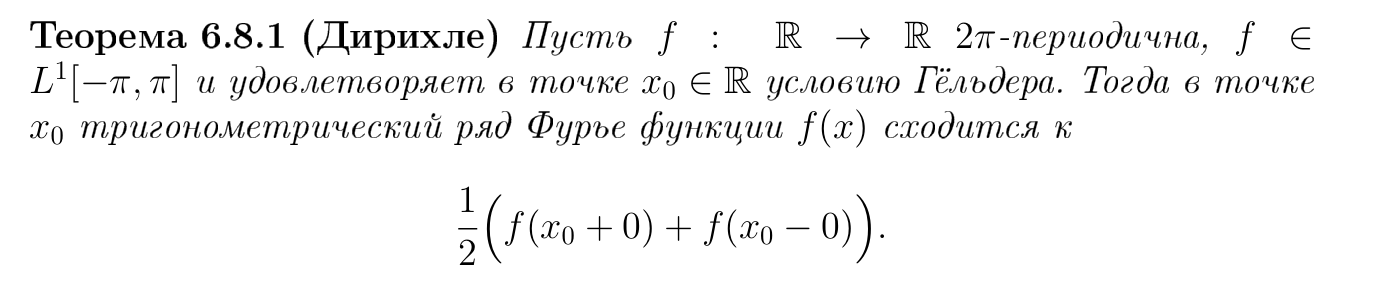